# 📬 Spam Classifier — Exploratory Data Analysis(EDA)

> *Before you build a model, become obsessed with the data.*
> *Every pattern you spot here is a bug you won't have to debug later.*

This notebook is **EDA only** — no modelling, no preprocessing pipeline, no train-test splits.
Its only job is to make you deeply familiar with what 5,574 SMS messages look like,
how they differ between spam and ham, and what traps are waiting for you if you skip this step.

Work through every section in order. By the end you should be able to answer:
- Is the dataset balanced? (spoiler: no)
- What does a typical spam message look like vs a typical ham?
- Which words are the strongest signal for each class?
- Are there any data quality issues to handle?

---

## 0 — Imports

Keep it minimal. This is exploration, not production.
`pandas` for the dataframe, `matplotlib` for plots, `collections.Counter` for word frequencies.
No sklearn, no nltk — you want to *see* the raw data, not abstract it away.

In [13]:
from enum import unique

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
import re
import string

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

---
## 1 — Load the raw data

The file is tab-separated with **no header row** and two columns:
- column 0: `label` — either the string `'ham'` or `'spam'`
- column 1: `message` — the raw SMS text, exactly as received

Some rows have extra tab-separated fields (artefacts from the original collection).
You only need the first two columns — use `usecols=[0, 1]` to ignore the rest.

After loading:
- Rename columns to `label` and `message`
- Print the shape and first 5 rows
- Check for null values — there should be none, but confirm

In [14]:
df = pd.read_csv(
    '/Users/piyushmaji/Desktop/ML_Project/Spam_sentiment_classifier/data/SMSSpamCollection',
    sep='\t',
    header=None,
    usecols=[0, 1],
    names=['label', 'message']
)

print(df.shape)
print(df.isnull().sum())    #if any coloumns contain any null values
df.head()

(5572, 2)
label      0
message    0
dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


---
## 2 — Class distribution

### Why this matters
Class imbalance is the first thing to check — and it will bite you if you ignore it.

Suppose 87% of your messages are ham and 13% are spam.
A model that **predicts ham for every single message** achieves 87% accuracy.
That sounds impressive until you realise it has caught exactly zero spam.
This is why you'll use **F1 score**, not accuracy, to evaluate your classifiers.

### What to do
- Count messages per class with `value_counts()`
- Compute the percentage split
- Plot a bar chart — keep it simple, two bars, labelled with counts
- Print one sentence summarising what the imbalance means for evaluation

label
ham     4825
spam     747
Name: count, dtype: int64
Spam is 13.4% of the dataset


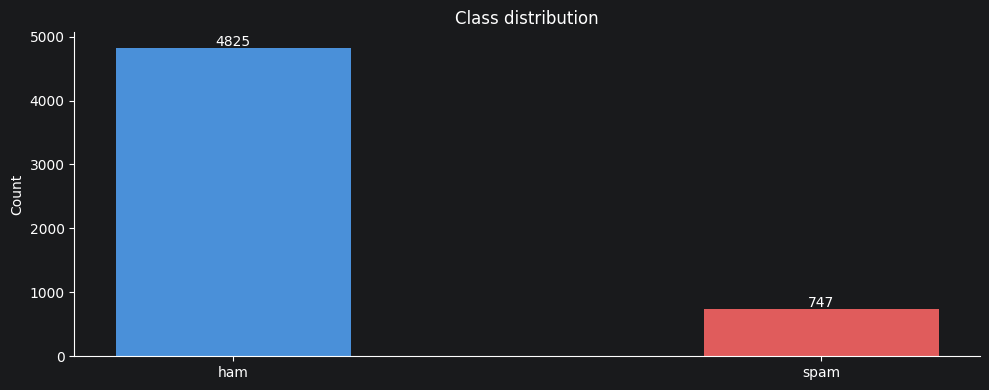

In [15]:
counts = df['label'].value_counts()
print(counts)
print(f"Spam is {counts['spam'] / len(df) * 100:.1f}% of the dataset")

# --- plot a bar chart ---
fig, ax = plt.subplots()                        # creates the canvas + the plot area
ax.bar(counts.index, counts.values, color=['#4A90D9', '#E05C5C'], width=0.4)
ax.set_title('Class distribution')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha='center')     #places a text label in each bar
plt.tight_layout()
plt.show()

---
## 3 — Message length distribution

### Why this matters
Spam messages tend to be either very short (a link and nothing else) or suspiciously long
(wall of text packed with keywords). Ham messages cluster around conversational lengths.

Message length alone is a weak classifier, but it's a useful sanity check:
if you see the distributions heavily overlap, length won't help your model much.
If they're clearly separated, your BoW features should do even better.

### What to do
- Add a `length` column: number of characters in each message
- Add a `word_count` column: number of whitespace-separated tokens
- For each class, print: min / max / mean / median length
- Plot overlapping histograms of character length — one colour per class, 50% opacity so both show
- Plot the same for word count
- Note any obvious visual separation between classes

       length                                                           \
        count        mean        std   min    25%    50%    75%    max   
label                                                                    
ham    4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0   
spam    747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0   

      word_count                                                      
           count       mean        std  min   25%   50%   75%    max  
label                                                                 
ham       4825.0  14.310259  11.517945  1.0   7.0  11.0  19.0  171.0  
spam       747.0  23.911647   5.780174  2.0  22.0  25.0  28.0   35.0  


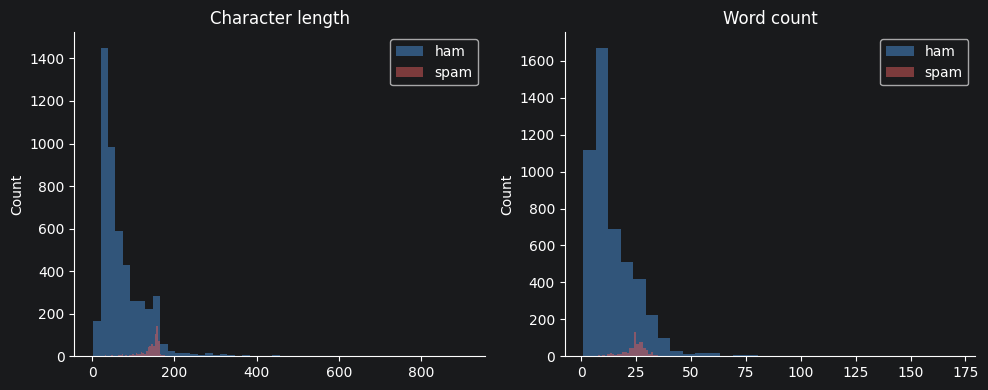

,label,message,length,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


In [16]:
df['length'] = df['message'].str.len()
df['word_count'] = df['message'].str.split().str.len()

# --- summary stats per class ---
print(df.groupby('label')[['length', 'word_count']].describe())
'''
--> df.groupby('label') # groups the DataFrame by the 'label' column, creating separate groups for 'ham' and 'spam'.
--> df.groupby('label')[['length', 'word_count']] # selects the 'length' and 'word_count' columns from the grouped DataFrame.
--> .describe() # computes summary statistics (like count, mean, std, min, 25th percentile, 50th percentile, 75th percentile, and max)
    for each group, providing insights into the distribution of message lengths and word counts for both 'ham' and 'spam' messages.
'''

# --- overlapping histograms ---
fig, axes = plt.subplots(1, 2)
for label, color in [('ham', '#4A90D9'), ('spam', '#E05C5C')]:
    subset = df[df['label'] == label]
    axes[0].hist(subset['length'],     bins=50, alpha=0.5, color=color, label=label)
    axes[1].hist(subset['word_count'], bins=30, alpha=0.5, color=color, label=label)
axes[0].set_title('Character length')
axes[1].set_title('Word count')
for ax in axes:
    ax.legend()
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
df.head()

---
## 4 — Top words per class

### Why this matters
This is the single most revealing thing you can do in EDA for a text classifier.
The words that appear most often in spam vs ham are exactly what Naive Bayes will learn to use.
If you can see the signal here with your eyes, the model will find it too.

You'll also spot stopwords ("the", "to", "a", "I") dominating both lists —
which is exactly why you'll remove them in preprocessing. They carry no class signal
and waste vocabulary space.

### What to do
- Split each class into its own list of messages
- Lowercase and tokenize by whitespace (rough, no cleaning yet — that's for `preprocessing.py`)
- Use `Counter` to count all tokens in each class
- Print top 20 words for spam and top 20 for ham side by side
- Plot two horizontal bar charts: top 15 spam words, top 15 ham words
- Ask yourself: which of these words would make a good feature? Which are noise?

TOP SPAM WORDS                 TOP HAM WORDS
to                   685        i                    2181
a                    375        you                  1669
call                 342        to                   1552
your                 263        the                  1125
you                  252        a                    1058
the                  204        u                    881
for                  202        and                  846
or                   188        in                   790
free                 180        my                   745
2                    169        is                   717
is                   152        me                   590
ur                   144        of                   519
on                   142        for                  502
txt                  136        that                 444
have                 135        it                   441
from                 127        have                 436
and                  122        but   

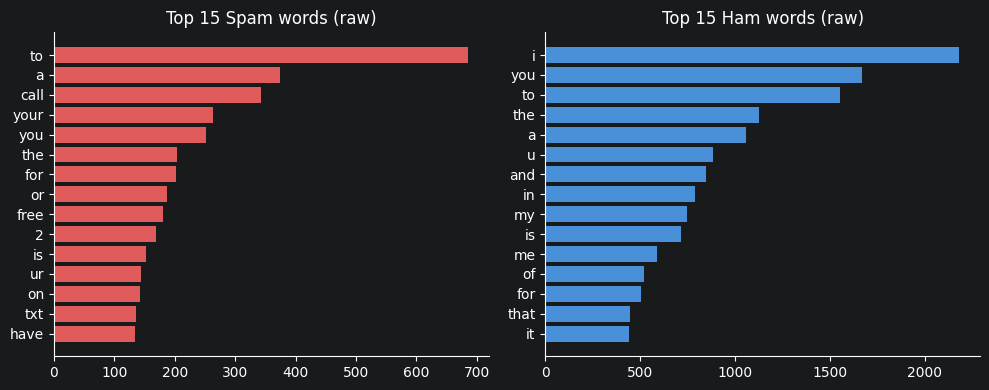

In [17]:
spam_words = Counter()
ham_words  = Counter()

for msg in df[df['label'] == 'spam']['message']:
    spam_words.update(msg.lower().split())
for msg in df[df['label'] == 'ham']['message']:
    ham_words.update(msg.lower().split())

# --- print top 20 side by side ---
print(f"{'TOP SPAM WORDS':<30} {'TOP HAM WORDS'}")
for (sw, sc), (hw, hc) in zip(spam_words.most_common(20), ham_words.most_common(20)):
    print(f"{sw:<20} {sc:<10} {hw:<20} {hc}")

# --- horizontal bar charts ---
fig, axes = plt.subplots(1, 2)
for ax, counter, label, color in [
    (axes[0], spam_words, 'Spam', '#E05C5C'),
    (axes[1], ham_words,  'Ham',  '#4A90D9')
]:
    words, counts = zip(*counter.most_common(15))
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(f'Top 15 {label} words (raw)')
plt.tight_layout()
plt.show()

---
## 5 — Top words after removing stopwords

### Why this matters
Section 4 showed you the raw word counts — probably dominated by "to", "the", "a", "I", "you".
These words appear in both classes at roughly equal rates, so they add noise, not signal.

This section strips them and re-runs the same analysis.
The difference between the two word clouds is your motivation for stopword removal in `preprocessing.py`.

### What to do
- Define a small stopword set (common English function words)
- Also strip punctuation from each token using `str.strip(string.punctuation)`
- Re-count spam and ham words with these tokens removed
- Plot the same two horizontal bar charts as section 4
- Note which genuinely spammy words now surface (FREE, CALL, WIN, PRIZE, URGENT…)

After Cleaning
TOP SPAM WORDS                 TOP HAM WORDS
call                 346        i'm                  372
free                 216        now                  289
now                  189        lt;#&gt              276
txt                  150        when                 274
ur                   144        ok                   273
from                 128        how                  256
mobile               123        ur                   246
text                 120        what                 243
stop                 115        all                  241
claim                113        got                  232
reply                101        know                 232
prize                92         like                 231
only                 79         call                 231
won                  73         come                 227
new                  69         good                 224
send                 68         then                 223
nokia                65     

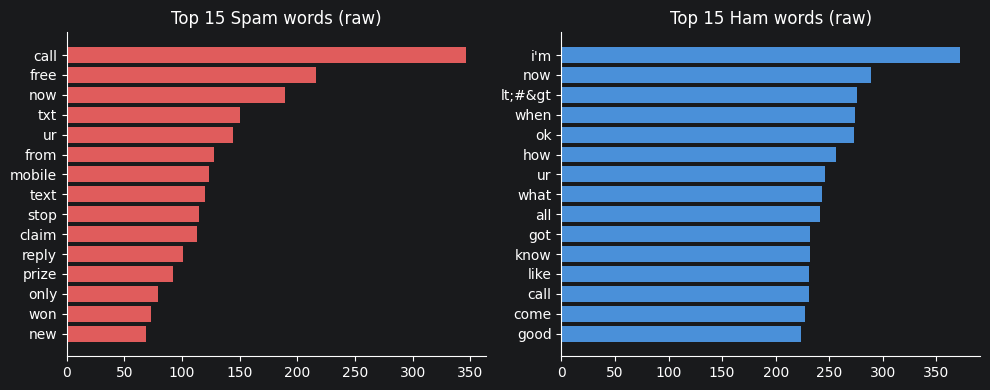

In [18]:
STOPWORDS = {
    'i', 'me', 'my', 'we', 'our', 'you', 'your', 'he', 'she', 'they', 'it',
    'is', 'are', 'was', 'were', 'be', 'been', 'have', 'has', 'had', 'do',
    'did', 'will', 'would', 'can', 'could', 'the', 'a', 'an', 'and', 'or',
    'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'this', 'that',
    'not', 'so', 'if', 'up', 'out', 'get', 'just', 'no', 'go', 'about'
}

def clean_tokens(text):
    tokens = text.lower().split()
    return [
        t.strip(string.punctuation)
        for t in tokens
        if t.strip(string.punctuation) not in STOPWORDS
        and len(t.strip(string.punctuation)) > 1
    ]

spam_clean = Counter()
ham_clean  = Counter()
for msg in df[df['label'] == 'spam']['message']:
    spam_clean.update(clean_tokens(msg))
for msg in df[df['label'] == 'ham']['message']:
    ham_clean.update(clean_tokens(msg))

# --- print top 20 side by side ---
print("After Cleaning")
print(f"{'TOP SPAM WORDS':<30} {'TOP HAM WORDS'}")
for (sw, sc), (hw, hc) in zip(spam_clean.most_common(20), ham_clean.most_common(20)):
    print(f"{sw:<20} {sc:<10} {hw:<20} {hc}")

# --- horizontal bar charts ---
fig, axes = plt.subplots(1, 2)
for ax, counter, label, color in [
    (axes[0], spam_clean, 'Spam', '#E05C5C'),
    (axes[1], ham_clean,  'Ham',  '#4A90D9')
]:
    words, counts = zip(*counter.most_common(15))
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(f'Top 15 {label} words (raw)')
plt.tight_layout()
plt.show()

---
## 6 — Unique vocabulary size vs class

### Why this matters
Spam messages often repeat a small set of high-impact words (FREE, CALL, WIN, NOW).
Ham messages use a much richer vocabulary — natural conversation covers more ground.

A large vocabulary means your BoW matrix will be wide and sparse.
Understanding the scale here helps you anticipate the shape of your feature matrix
before you write a line of preprocessing code.

### What to do
- Count unique tokens in spam messages and unique tokens in ham messages (after cleaning)
- Count unique tokens in the full corpus
- Print: `vocab size (spam)`, `vocab size (ham)`, `vocab size (total)`
- Compute and print vocabulary **overlap**: words that appear in both classes
- Compute words **exclusive to spam** — these are your sharpest features
- Print 20 spam-exclusive words — do they look like what you expected?

In [25]:
vocab_spam = set(spam_clean.keys())
vocab_ham  = set(ham_clean.keys())

overlap        = vocab_spam & vocab_ham         # intersection
unique         = vocab_spam | vocab_ham         # union

spam_exclusive = vocab_spam - vocab_ham
ham_exclusive  = vocab_ham  - vocab_spam

print(f"Spam vocab size     : {len(vocab_spam)}")
print(f"Ham vocab size      : {len(vocab_ham)}")
print(f"Total unique tokens : {len(unique)}")
print(f"Overlap             : {len(overlap)} words appear in both classes")
print(f"Spam-exclusive      : {len(spam_exclusive)}")
print()
print("20 spam-exclusive words by frequency:")
spam_exclusive_freq = {w: spam_clean[w] for w in spam_exclusive}
top_exclusive = sorted(spam_exclusive_freq, key=spam_exclusive_freq.get, reverse=True)[:20]
print(top_exclusive)

Spam vocab size     : 3013
Ham vocab size      : 7680
Total unique tokens : 9723
Overlap             : 970 words appear in both classes
Spam-exclusive      : 2043

20 spam-exclusive words by frequency:
['claim', 'prize', 'won', 'guaranteed', 'tone', '18', 'awarded', '£1000', '150ppm', 'entry', 'ringtone', 'collection', 'tones', 'mob', 'weekly', 'valid', '500', '£100', '150p', '8007']


---
## 7 — Special character analysis

### Why this matters
Spam messages use punctuation as a weapon: `!!!`, `£££`, `$$$`, `???`.
These won't survive standard tokenization (you strip punctuation in `clean_text()`).
Before you throw them away, check whether they're actually informative.

This is a decision you'll make consciously, not by accident.

### What to do
- For each class, compute the **average number of exclamation marks** per message
- For each class, compute the **average number of uppercase letters** per message
- For each class, compute the **frequency of £ and $ signs**
- Print a small summary table: metric | ham mean | spam mean
- Decide: will you keep any of these as engineered features in `preprocessing.py`?
  Write your reasoning in the markdown cell below

In [24]:
df['exclamations'] = df['message'].str.count(r'!')          # regex pattern
df['uppercase']    = df['message'].apply(lambda x: sum(1 for c in x if c.isupper()))
df['currency']     = df['message'].str.count(r'[£$]')

summary = df.groupby('label')[['exclamations', 'uppercase', 'currency']].mean()
print(summary.round(2))

       exclamations  uppercase  currency
label                                   
ham            0.18       4.11      0.00
spam           0.73      15.47      0.44


**Your decision:**

*Write here whether you'll keep any of these as hand-crafted features, and why or why not.
If the spam mean is dramatically higher than ham for a feature, it might be worth keeping even after
you strip punctuation. If the difference is small, dropping it is fine.*

---
## 8 — Sample messages

### Why this matters
Numbers and charts summarise, but they can hide things.
Reading actual messages is irreplaceable — you'll spot patterns no plot would show:
messages in different languages, messages that are clearly mislabelled,
or ham messages that look suspiciously spammy.

A good ML practitioner reads their data. Always.

### What to do
- Print 10 random spam messages (set a seed so it's reproducible)
- Print 10 random ham messages
- Print the 5 **longest** spam messages in full
- Print the 5 **shortest** spam messages in full
- Note anything surprising in the markdown cell below

In [29]:
spam_df = df[df['label'] == 'spam'].reset_index(drop=True)      #pandas keeps orginal indices so we have to reset it
ham_df  = df[df['label'] == 'ham'].reset_index(drop=True)

print("=== 10 random SPAM messages ===")
for msg in spam_df['message'].sample(10, random_state=42):
    print(' •', msg)

print("\n=== 10 random HAM messages ===")
for msg in ham_df['message'].sample(10, random_state=42):
    print(' •', msg)

print("\n=== 5 longest SPAM messages ===")
for msg in spam_df.nlargest(5, 'length')['message']:
    print(' •', msg, '\n')

print("=== 5 shortest SPAM messages ===")
for msg in spam_df.nsmallest(5, 'length')['message']:
    print(' •', msg)

=== 10 random SPAM messages ===
 • Summers finally here! Fancy a chat or flirt with sexy singles in yr area? To get MATCHED up just reply SUMMER now. Free 2 Join. OptOut txt STOP Help08714742804
 • This is the 2nd time we have tried 2 contact u. U have won the 750 Pound prize. 2 claim is easy, call 08718726970 NOW! Only 10p per min. BT-national-rate 
 • Get ur 1st RINGTONE FREE NOW! Reply to this msg with TONE. Gr8 TOP 20 tones to your phone every week just £1.50 per wk 2 opt out send STOP 08452810071 16
 • Ur cash-balance is currently 500 pounds - to maximize ur cash-in now send GO to 86688 only 150p/msg. CC: 08718720201 PO BOX 114/14 TCR/W1
 • Last Chance! Claim ur £150 worth of discount vouchers today! Text SHOP to 85023 now! SavaMob, offers mobile! T Cs SavaMob POBOX84, M263UZ. £3.00 Sub. 16
 • You can stop further club tones by replying "STOP MIX" See my-tone.com/enjoy. html for terms. Club tones cost GBP4.50/week. MFL, PO Box 1146 MK45 2WT (2/3)
 • For ur chance to win a £250 cas

**What you noticed:**

*Write any surprises here — unusual messages, potential mislabels, edge cases, non-English text.
This is where EDA pays off: catching problems before they silently hurt your model.*

---
## 9 — Duplicate messages

### Why this matters
Duplicates in a dataset are a silent accuracy inflator.
If the same message appears in both train and test (because you split after deduplication),
your model gets credit for "predicting" something it literally memorised.
You need to know how many duplicates exist and deduplicate **before** splitting.

### What to do
- Count exact duplicate messages (same text, any label)
- Count duplicates within the spam class and within the ham class separately
- Check: are there any messages that appear as both spam **and** ham? (contradictory labels)
- Print how many rows would be dropped if you deduplicated
- Make a note in `preprocessing.py` to call `.drop_duplicates()` before splitting

In [32]:
total_dupes = df.duplicated(subset='message').sum()
print(f"Total duplicate messages : {total_dupes}")

spam_dupes = spam_df.duplicated(subset='message').sum()
ham_dupes  = ham_df.duplicated(subset='message').sum()
print(f"Spam duplicates : {spam_dupes}")
print(f"Ham duplicates  : {ham_dupes}")

# --- check for contradictory labels ---
label_per_msg = df.groupby('message')['label'].nunique()
contradictions = label_per_msg[label_per_msg > 1]
print(f"Messages with contradictory labels: {len(contradictions)}")
if len(contradictions) > 0:
    print(contradictions.index.tolist())

Total duplicate messages : 403
Spam duplicates : 94
Ham duplicates  : 309
Messages with contradictory labels: 0


---
## 10 — EDA summary & preprocessing decisions

### Fill this in before you write a single line of `preprocessing.py`

This is the most important cell in the notebook.
Everything you observed above should translate into a concrete decision here.
If you can't fill this in, go back and look harder at the data.

| Question | Your answer |
|----------|-------------|
| Is the dataset balanced? | |
| What evaluation metric will you use instead of accuracy, and why? | |
| Do you need to deduplicate before splitting? | |
| Which stopwords will you remove? (hardcoded set or nltk?) | |
| Will you keep any punctuation-based features (!, £, uppercase count)? | |
| What is the approximate vocabulary size you expect after cleaning? | |
| Are there any non-English messages? How will you handle them? | |
| Which words showed the strongest spam signal? List 5. | |
| Any data quality issues to flag before modelling? | |

---

> *You are now ready to write `preprocessing.py`.*
> *Every function you implement there should feel obvious — because you've already seen what the data needs.*